# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [12]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [13]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "191848"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v65250145
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,-0.777651,-0.234459,1.108896,2.785034,-1.400466,8.597518,1.134113,0.386313,-0.252589,3.211620,32.325798,-0.155050,16.756955
1,-1.709381,0.093554,1.687472,-1.192003,-0.870991,0.755000,0.802714,-0.155257,-1.213949,3.819667,63.194842,0.419766,35.564378
2,-0.428594,-0.369855,-0.122945,1.354077,0.245284,1.131881,7.301925,-0.708543,-0.041101,0.417050,15.867235,-0.326495,9.773942
3,1.514324,0.365746,0.700516,2.574990,-1.867428,1.435047,1.031083,-0.513434,0.935062,2.327291,6.860784,0.251303,37.148807
4,-0.637712,0.295929,1.098633,0.284204,0.381076,0.392049,0.939438,-1.459177,-0.454181,0.685528,52.754459,-0.348743,6.369704


In [14]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?

# Primer vistazo: rangos, faltantes y asimetría de cada variable.
print("Faltantes en train:", int(train.isna().sum().sum()), "| en test:", int(test.isna().sum().sum()))
resumen = train.describe().T
resumen["asimetria"] = train.skew()
resumen.round(3)

Faltantes en train: 0 | en test: 0


,count,mean,std,min,25%,50%,75%,max,asimetria
x1,800.0,0.035,1.157,-1.999,-0.945,0.068,1.072,1.990,-0.051
x2,800.0,0.014,0.290,-0.499,-0.232,0.019,0.273,0.496,-0.058
x3,800.0,0.049,1.153,-1.973,-0.932,0.031,1.059,1.999,-0.042
x4,800.0,0.052,1.693,-2.998,-1.327,0.026,1.496,2.996,-0.009
x5,800.0,-0.028,1.664,-2.993,-1.380,-0.088,1.322,2.997,0.016
x6,800.0,1.686,2.030,0.035,0.530,1.069,2.143,20.417,3.766
x7,800.0,1.612,2.563,0.024,0.459,0.896,1.847,46.825,8.542
x8,800.0,-0.015,1.045,-4.042,-0.659,-0.011,0.651,2.892,-0.019
x9,800.0,-0.003,0.993,-3.478,-0.695,0.026,0.650,3.369,-0.082
x10,800.0,2.007,1.187,0.008,0.935,2.006,2.995,3.996,-0.001


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 135.20
R² del baseline en validación : 0.395

Desviación estándar de y: 13.93


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

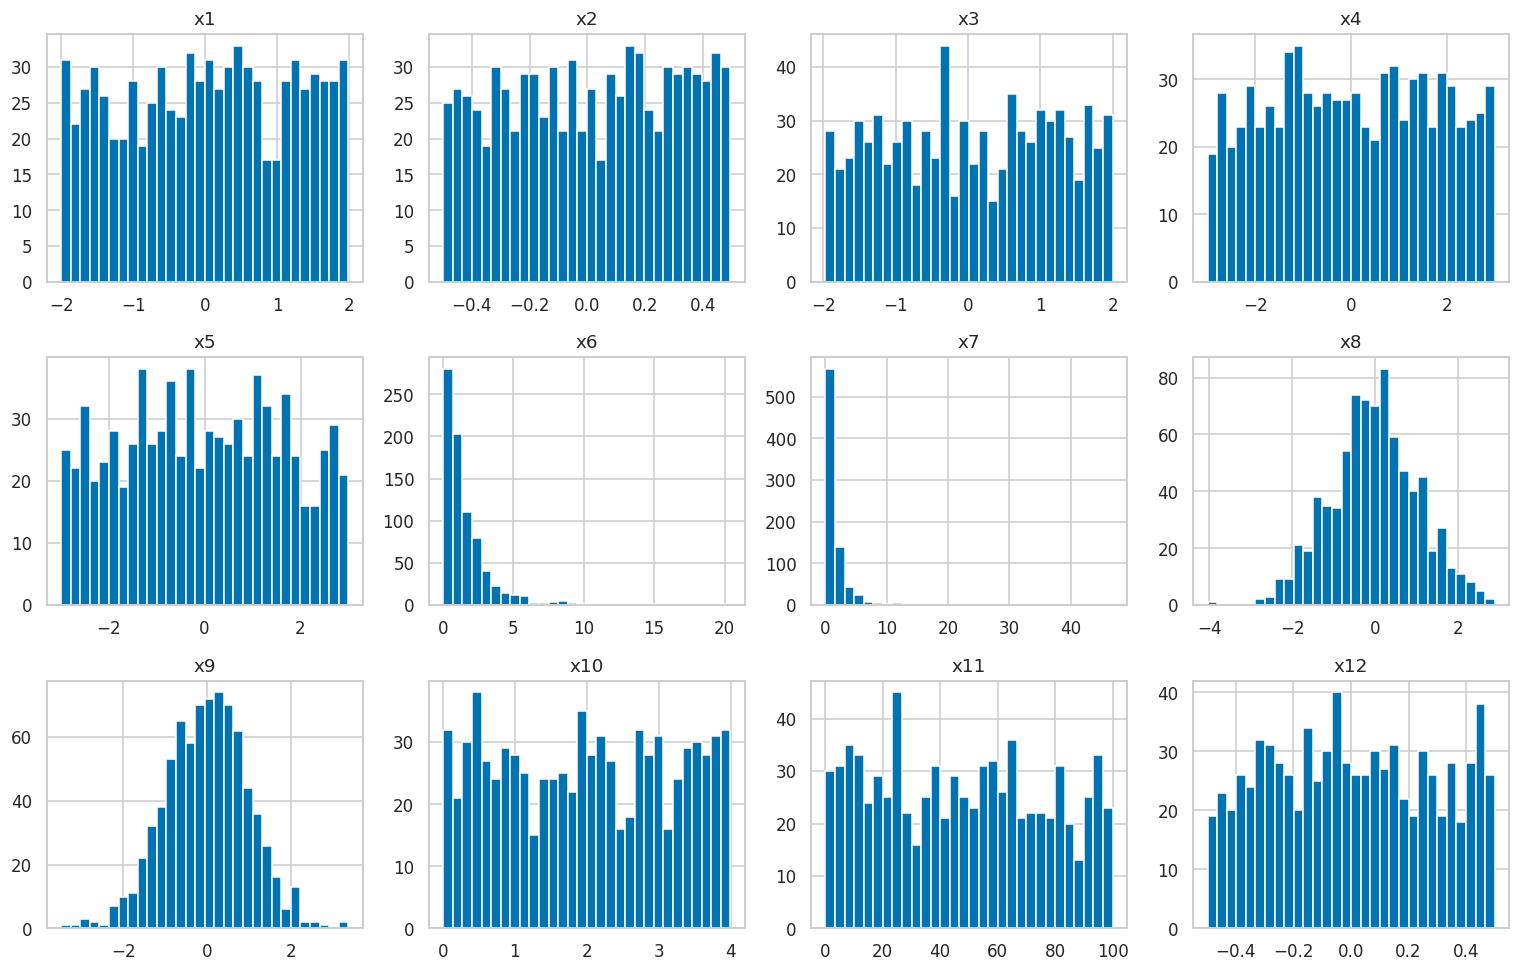

In [16]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.

# Distribución de cada una de las 12 variables.
train[VARIABLES].hist(bins=30, figsize=(14, 9), layout=(3, 4))
plt.tight_layout()
plt.show()

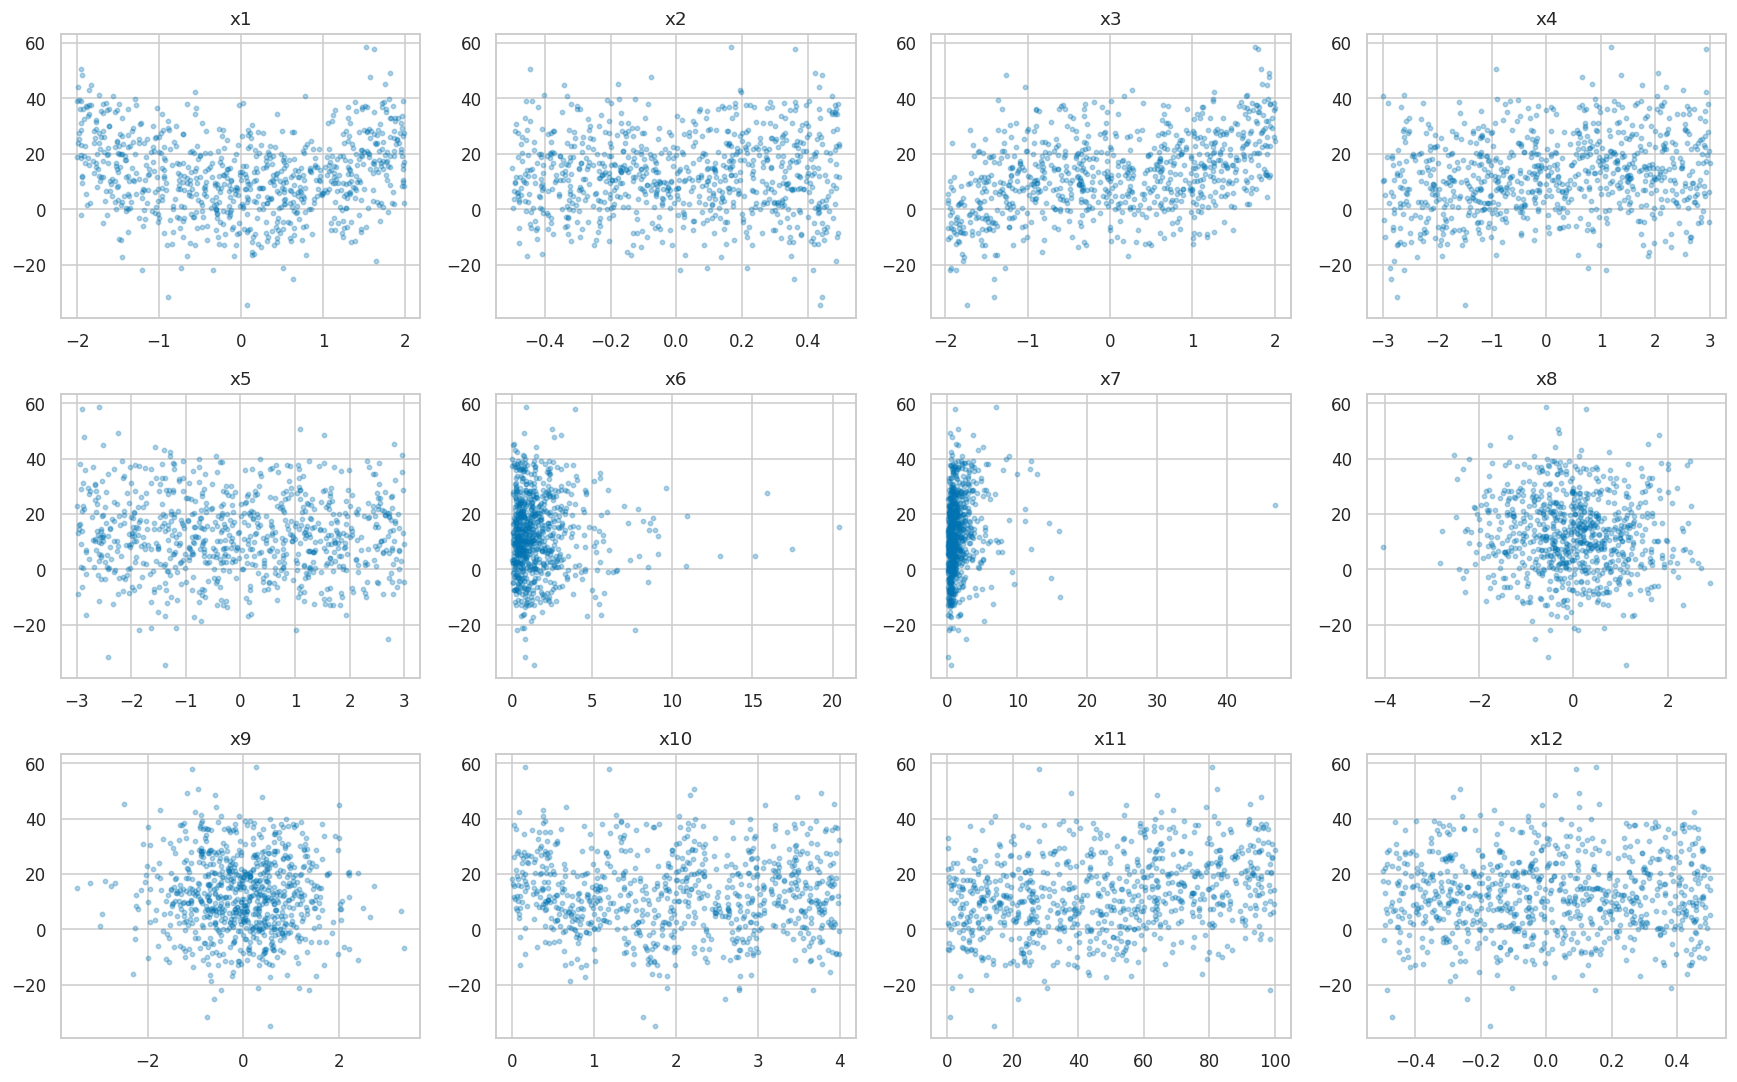

In [17]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.

# `y` contra cada variable, con transparencia porque 800 puntos se traslapan.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, var in zip(axes.ravel(), VARIABLES):
    ax.scatter(train[var], train["y"], s=8, alpha=0.3)
    ax.set_title(var)
plt.tight_layout()
plt.show()

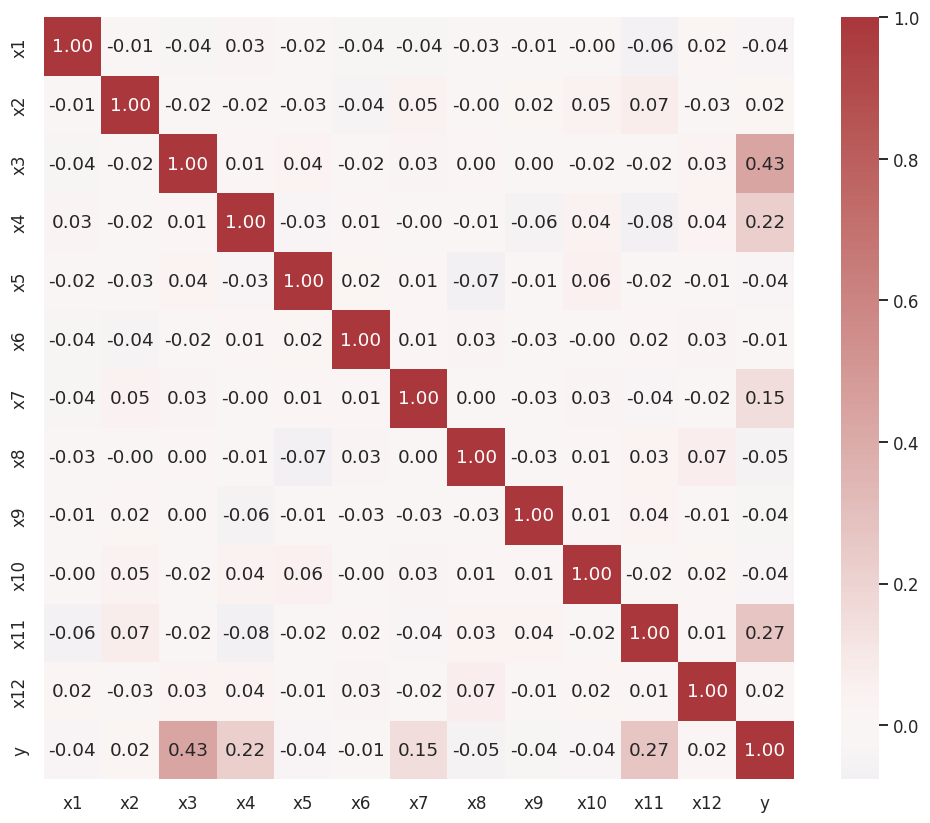

In [18]:
# TODO: matriz de correlación entre las 12 variables y `y`.

# Matriz de correlación (Pearson) entre las 12 variables y `y`.
plt.figure(figsize=(11, 9))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.show()

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| x1 | En la dispersion se ve U: y es alta en las dos orillas y baja en medio. parece un cuadrado  | y vs x1 | Alto |
| x2 | No veo nada, la nube está plana. | y vs x2 | Medio |
| x3 | Sube. Parece una S, parece un cubo o un seno | y vs x3 | Medio |
| x4 | Sube un poquito, parece recta. | y vs x4 | Medio |
| x5 | No veo nada. | y vs x5 | Medio |
| x6 | Casi todos los puntos están amontonados a la izquierda y hay unos pocos muy lejos. En el scatter no se ve nada. Tal vez con logaritmo se vea algo. | Histograma | Bajo |
| x7 | Igual que x6 pero más exagerada. En el scatter no se distingue nada por lo amontonado. Tal vez logaritmo. | Histograma | Bajo |
| x8 | No veo nada. | y vs x8 | Medio |
| x9 | No veo nada. | y vs x9 | Medio |
| x10 | La orilla de abajo de la nube se ve como con ondas que se repiten. No estoy seguro de si es real o casualidad. | y vs x10 | Bajo |
| x11 | Sube un poco, parece una rampa normal. | y vs x11 | Medio |
| x12 | No veo nada. | y vs x12 | Medio |

**Relectura al final de la tarea.**

- Le atiné: x1 era un cuadrado y x10 un seno.
- Le atiné a medias: x3 sí tenía efecto, pero no era un seno sino un cubo, y eso solo se vio en los
  residuales. x7 sí era logaritmo, pero lo adiviné por el histograma, no porque lo viera en el scatter.
- Me equivoqué: x11 no era una rampa sino un salto en 60. A simple vista no se distingue; salió hasta
  que saqué el promedio del residual por tramos. Y x6 fue falsa alarma: está igual de cargada a la
  izquierda que x7 pero no tiene ningún efecto.
- El error más grande: x2.  Aquí puse "no veo nada" y resultó ser la mitad del efecto más importante
  de todo el modelo (x2*x4). Ninguna gráfica de una sola variable lo podía mostrar.

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [19]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 135.20


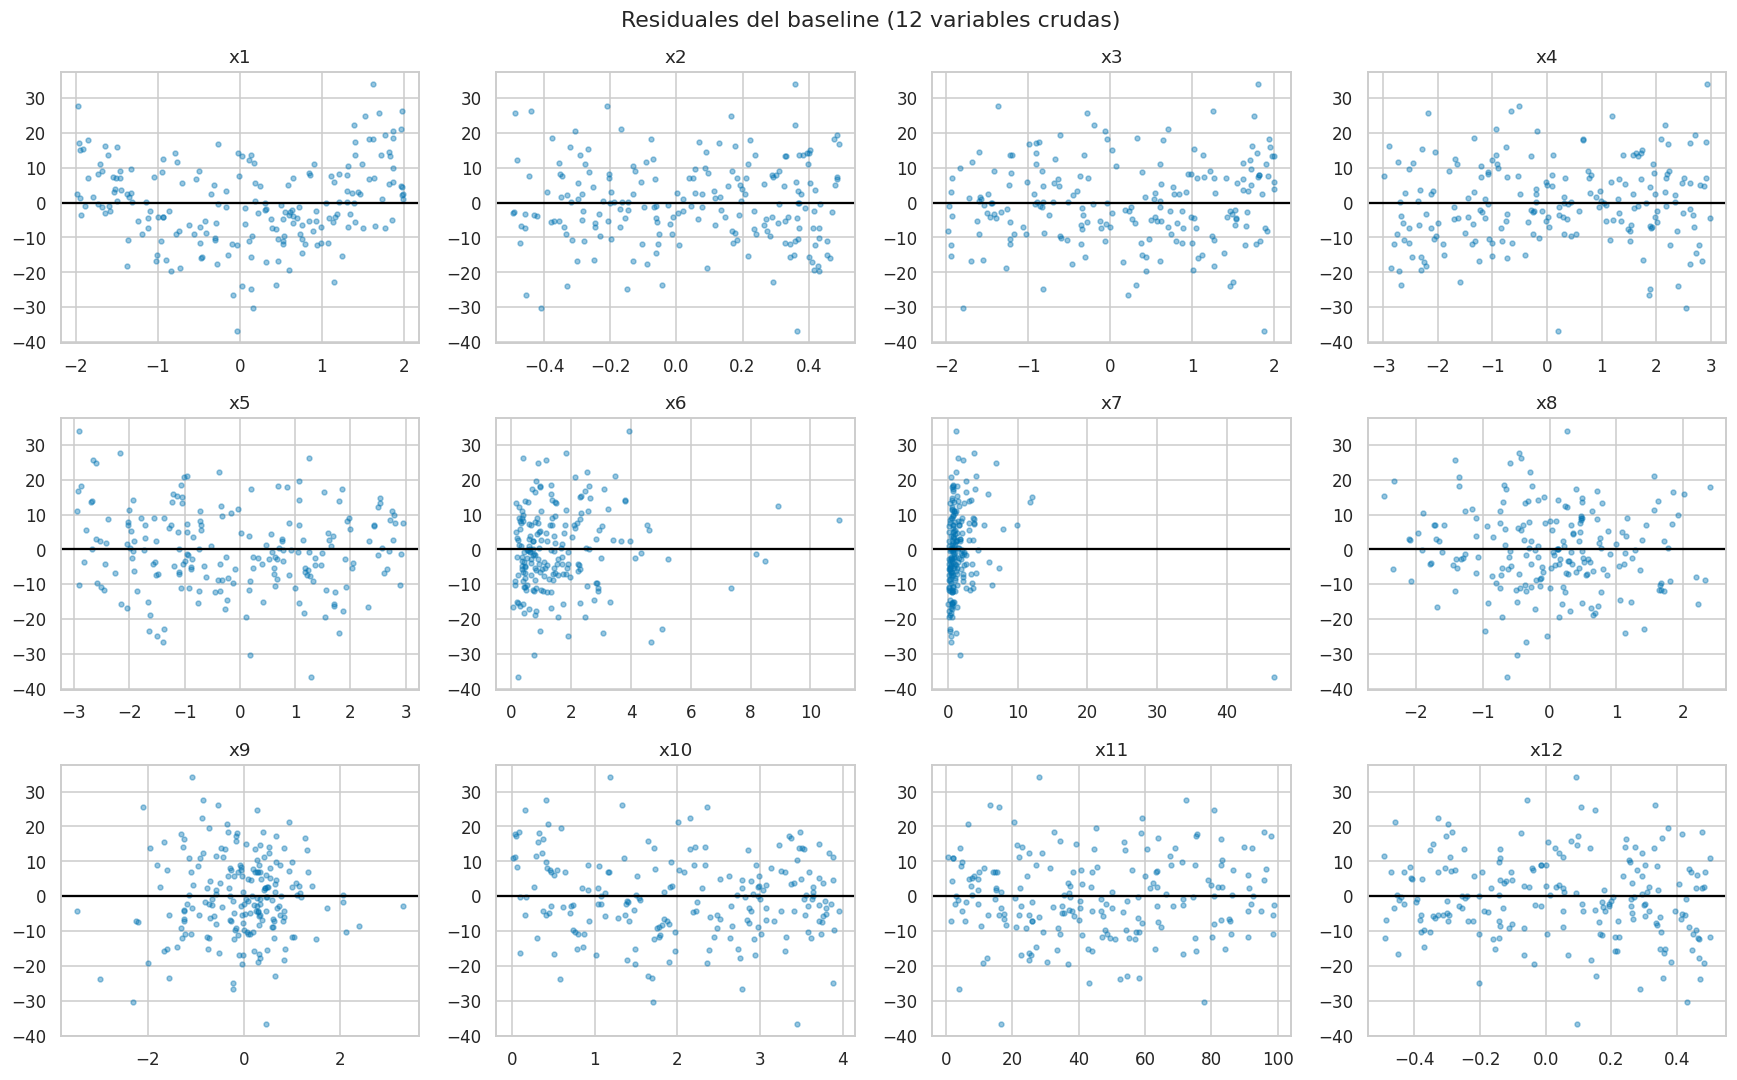

In [20]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.

def grafica_residuales(residuales, titulo):
    """Residuales de validación contra cada una de las 12 variables."""
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    for ax, var in zip(axes.ravel(), VARIABLES):
        ax.scatter(X_val[var], residuales, s=10, alpha=0.4)
        ax.axhline(0, color="black")
        ax.set_title(var)
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()


grafica_residuales(residuales, "Residuales del baseline (12 variables crudas)")

Con |x1| -> MSE 102.25
Con x1²  -> MSE 99.15


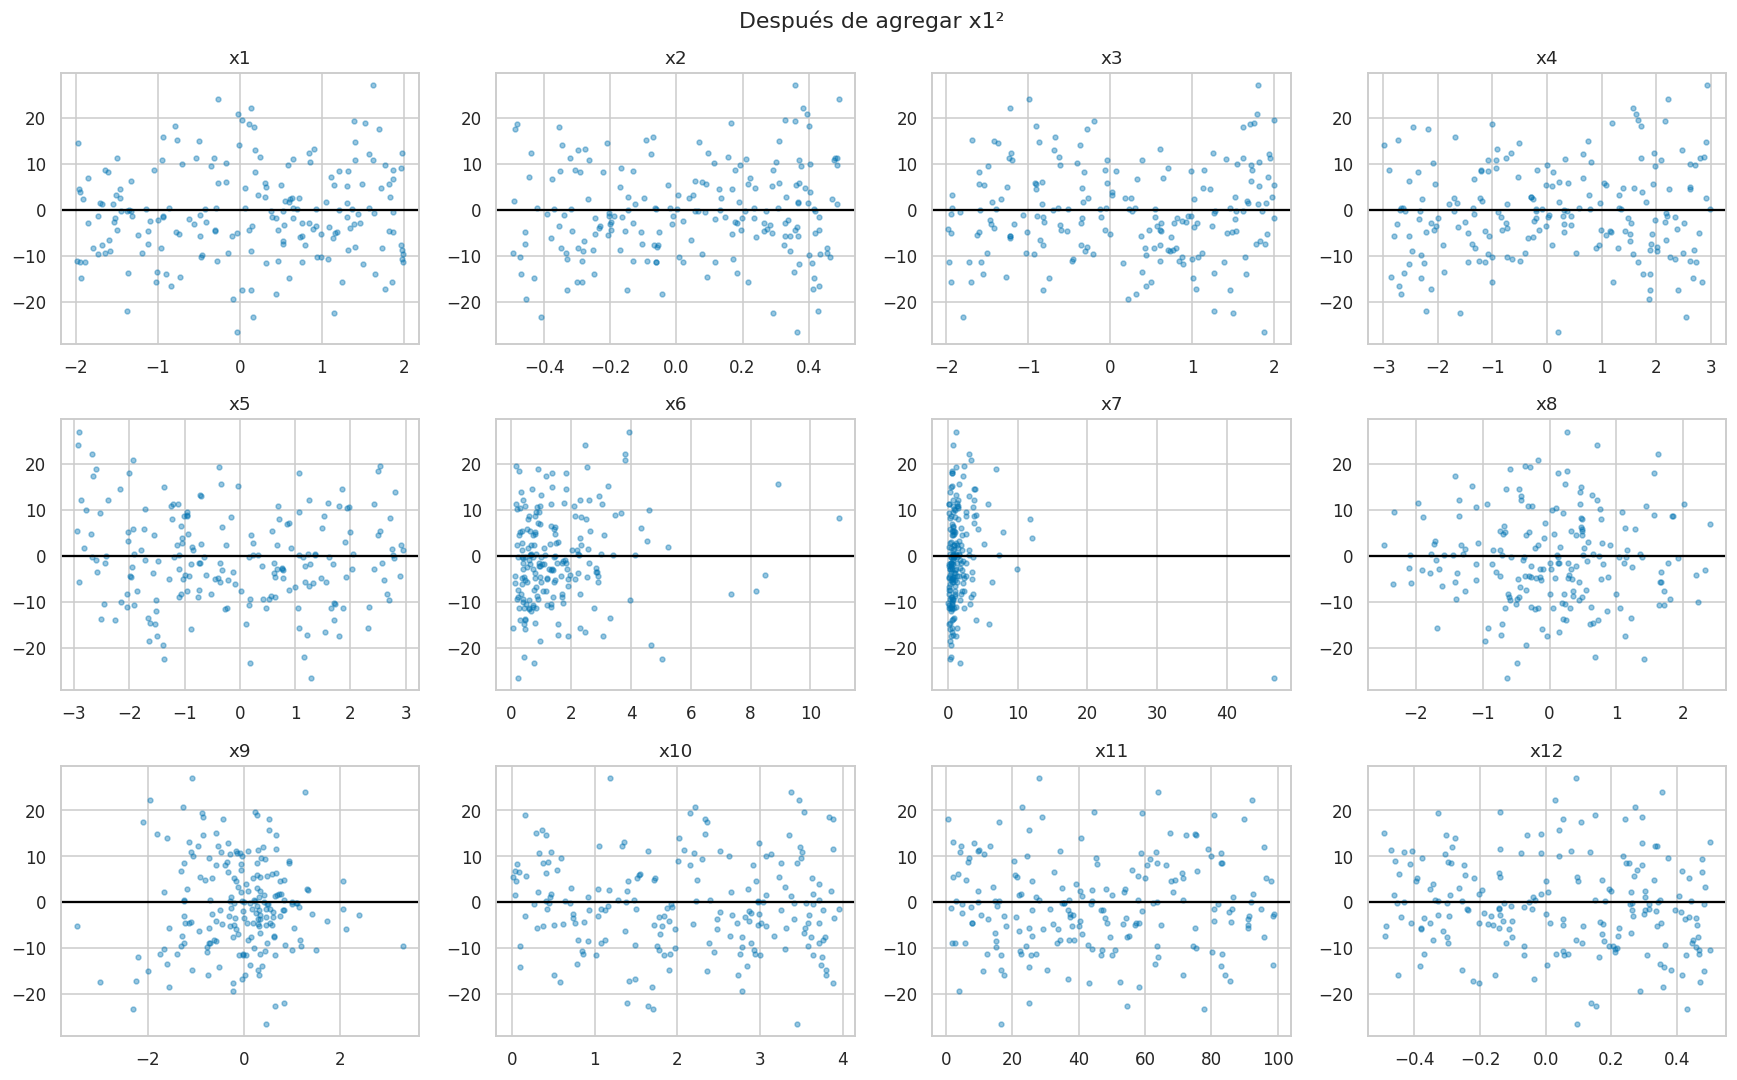

In [21]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.

# Hipótesis 1: el residual contra x1 tiene forma de U. Dos candidatos: |x1| y x1².

# Candidato A: valor absoluto
modelo, mse, residuales, _ = ajusta({"x1_abs": lambda d: d["x1"].abs()})
print(f"Con |x1| -> MSE {mse:.2f}")

# Candidato B: cuadrado
modelo, mse, residuales, _ = ajusta({"x1_sq": lambda d: d["x1"] ** 2})
print(f"Con x1²  -> MSE {mse:.2f}")

# Gana el cuadrado. En este diccionario voy acumulando los términos que se quedan.
terminos = {}
terminos["x1_sq"] = lambda d: d["x1"] ** 2

modelo, mse, residuales, _ = ajusta(terminos)
grafica_residuales(residuales, "Después de agregar x1²")

In [22]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
#
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.

# Hipótesis 2: x6 y x7 son positivas con cola derecha muy larga -> logaritmo.

# Pruebo log(x6): lo agrego, mido y, como no sirve, lo quito.
terminos["log_x6"] = lambda d: np.log(d["x6"])
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Con log(x6) -> MSE {mse:.2f}   (antes 99.15: no ayuda, callejón sin salida)")
del terminos["log_x6"]

# Pruebo log(x7): este sí se queda.
terminos["log_x7"] = lambda d: np.log(d["x7"])
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Con log(x7) -> MSE {mse:.2f}")

Con log(x6) -> MSE 99.37   (antes 99.15: no ayuda, callejón sin salida)
Con log(x7) -> MSE 95.90


Con sin(2π·x10) -> MSE 75.09
Con cos(2π·x10) además -> MSE 75.26   (no ayuda, callejón sin salida)


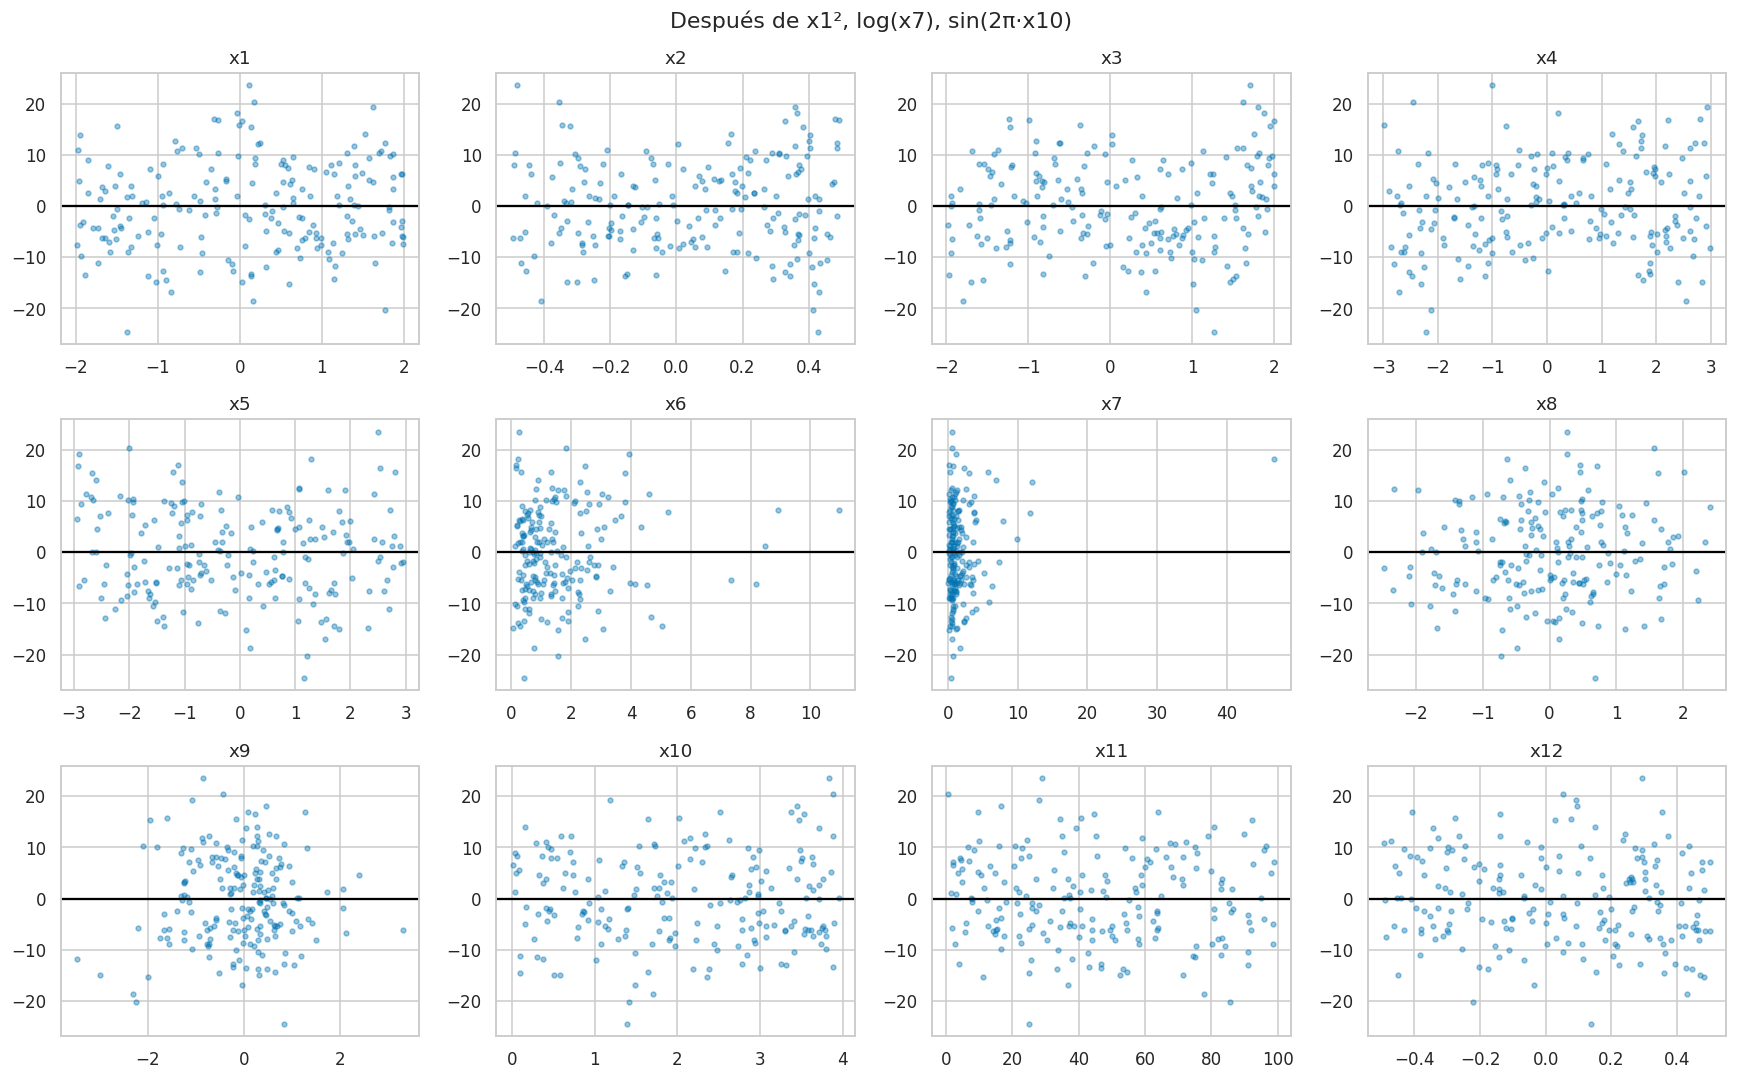

In [23]:
# Hipótesis 3: el residual contra x10 ondula con picos cada ~1 unidad -> periodo 1 -> sin(2π·x10).
terminos["sin_x10"] = lambda d: np.sin(2 * np.pi * d["x10"])
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Con sin(2π·x10) -> MSE {mse:.2f}")

# ¿La onda tiene desfase? Si lo tuviera, el coseno de la misma frecuencia ayudaría.
terminos["cos_x10"] = lambda d: np.cos(2 * np.pi * d["x10"])
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Con cos(2π·x10) además -> MSE {mse:.2f}   (no ayuda, callejón sin salida)")
del terminos["cos_x10"]

modelo, mse, residuales, _ = ajusta(terminos)
grafica_residuales(residuales, "Después de x1², log(x7), sin(2π·x10)")

Con x3² -> MSE 77.13   (antes 75.09: empeora, callejón sin salida)
Con x3³ -> MSE 62.16


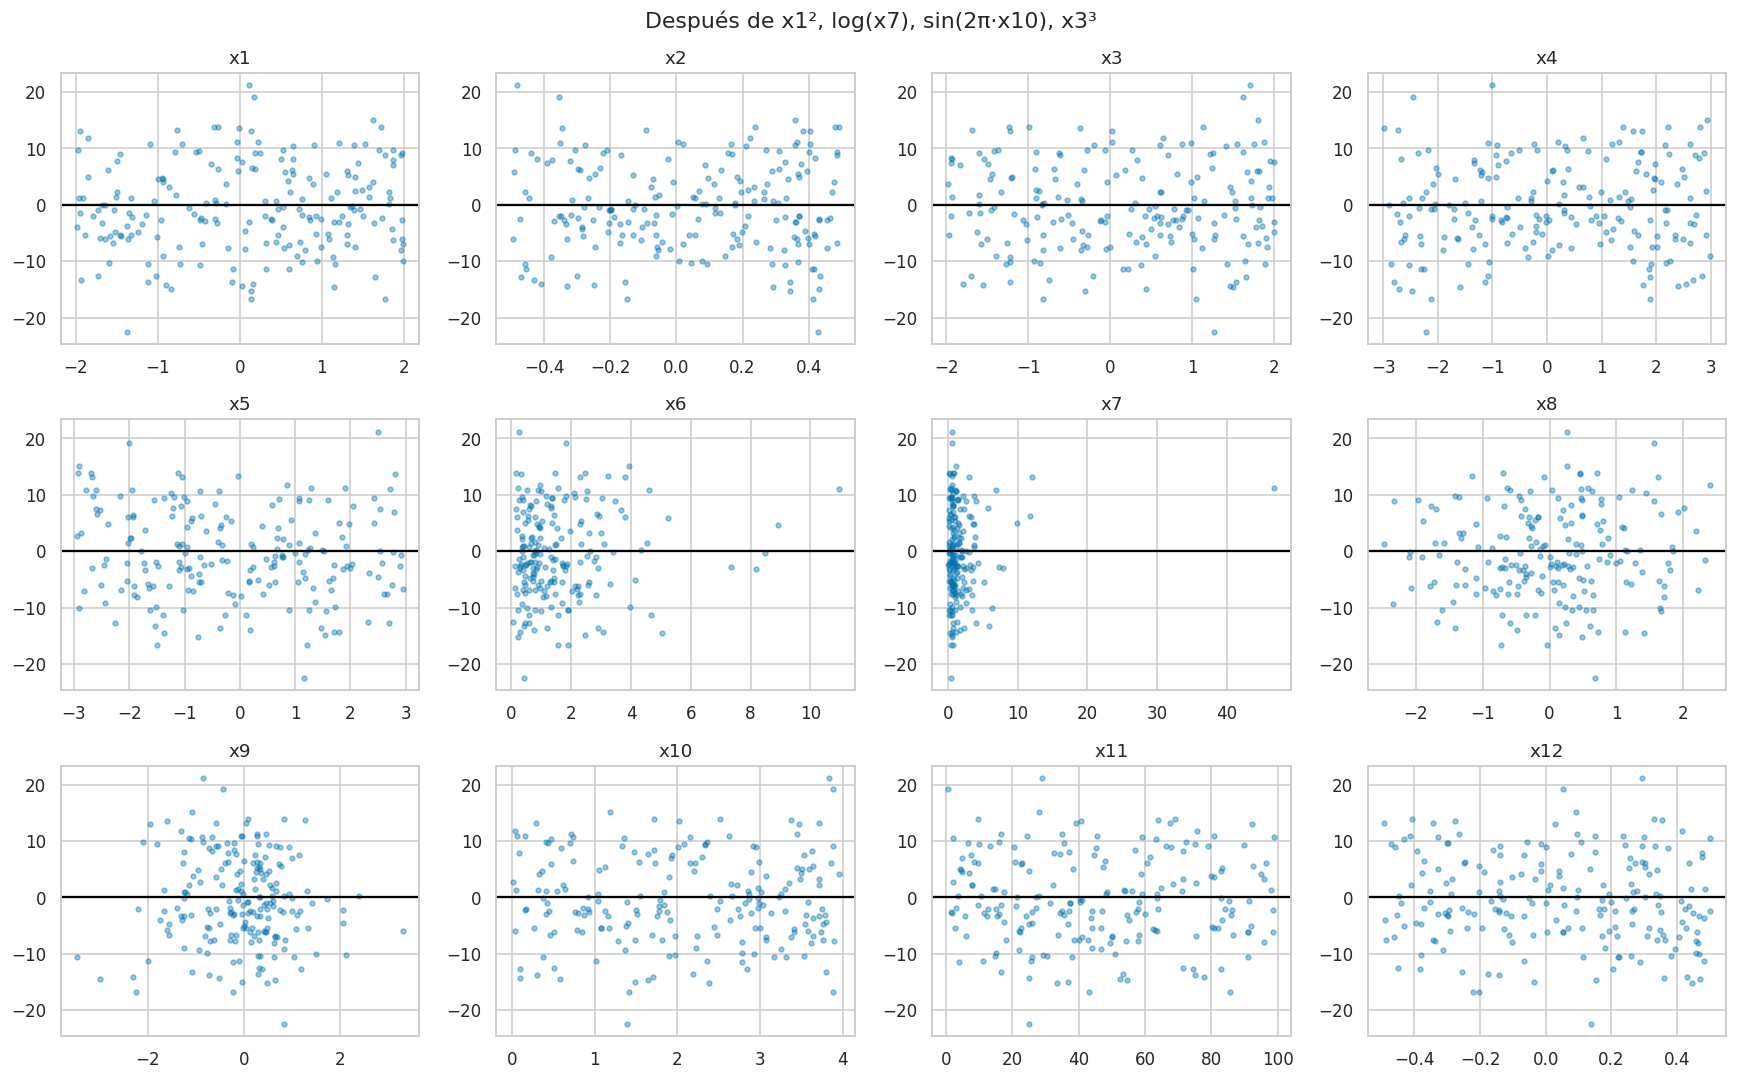

In [24]:
# Hipótesis 4: el residual contra x3 tiene forma de S (sube, baja, sube).
# Un cuadrado es simétrico y no puede hacer una S; un cubo sí. Pruebo los dos.
terminos["x3_sq"] = lambda d: d["x3"] ** 2
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Con x3² -> MSE {mse:.2f}   (antes 75.09: empeora, callejón sin salida)")
del terminos["x3_sq"]

terminos["x3_cu"] = lambda d: d["x3"] ** 3
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Con x3³ -> MSE {mse:.2f}")

grafica_residuales(residuales, "Después de x1², log(x7), sin(2π·x10), x3³")

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [25]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.

# Una interacción a·b no se ve variable por variable, pero el PRODUCTO sí correlaciona con el
# residual. Estandarizo primero para que el producto mida "las dos altas o las dos bajas a la vez".
Z = (X_val - X_val.mean()) / X_val.std()

resultados = []
for i in range(12):
    for j in range(i + 1, 12):          # los 66 pares, sin repetir
        a = VARIABLES[i]
        b = VARIABLES[j]
        r = np.corrcoef(Z[a] * Z[b], residuales)[0, 1]
        resultados.append((abs(r), a, b))

resultados.sort(reverse=True)
for r, a, b in resultados[:5]:
    print(f"{a} * {b}: |r| = {r:.2f}")

x2 * x4: |r| = 0.68
x2 * x3: |r| = 0.17
x4 * x11: |r| = 0.17
x2 * x10: |r| = 0.15
x2 * x5: |r| = 0.14


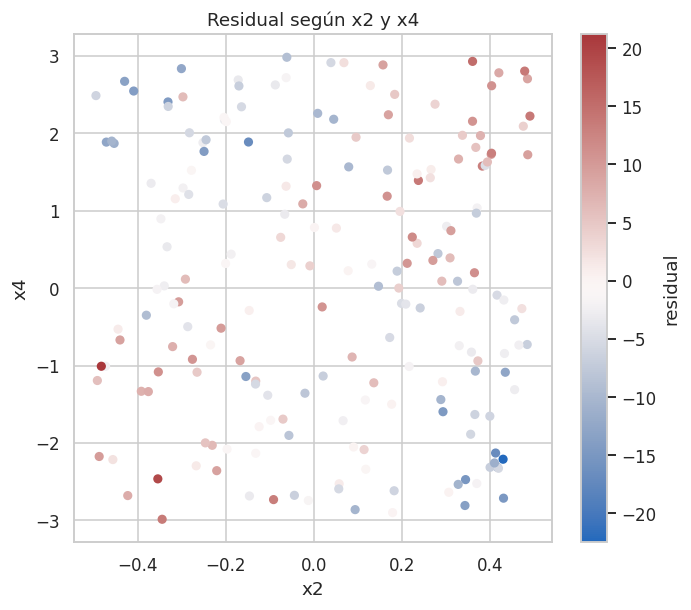

In [26]:
# La gráfica que lo prueba: residual coloreado en el plano (x2, x4).
# Un producto deja firma de tablero: dos esquinas opuestas rojas y las otras dos azules.
plt.figure(figsize=(7, 6))
plt.scatter(X_val["x2"], X_val["x4"], c=residuales, cmap="vlag", s=25)
plt.colorbar(label="residual")
plt.xlabel("x2")
plt.ylabel("x4")
plt.title("Residual según x2 y x4")
plt.show()

Con x2·x4 -> MSE 31.19


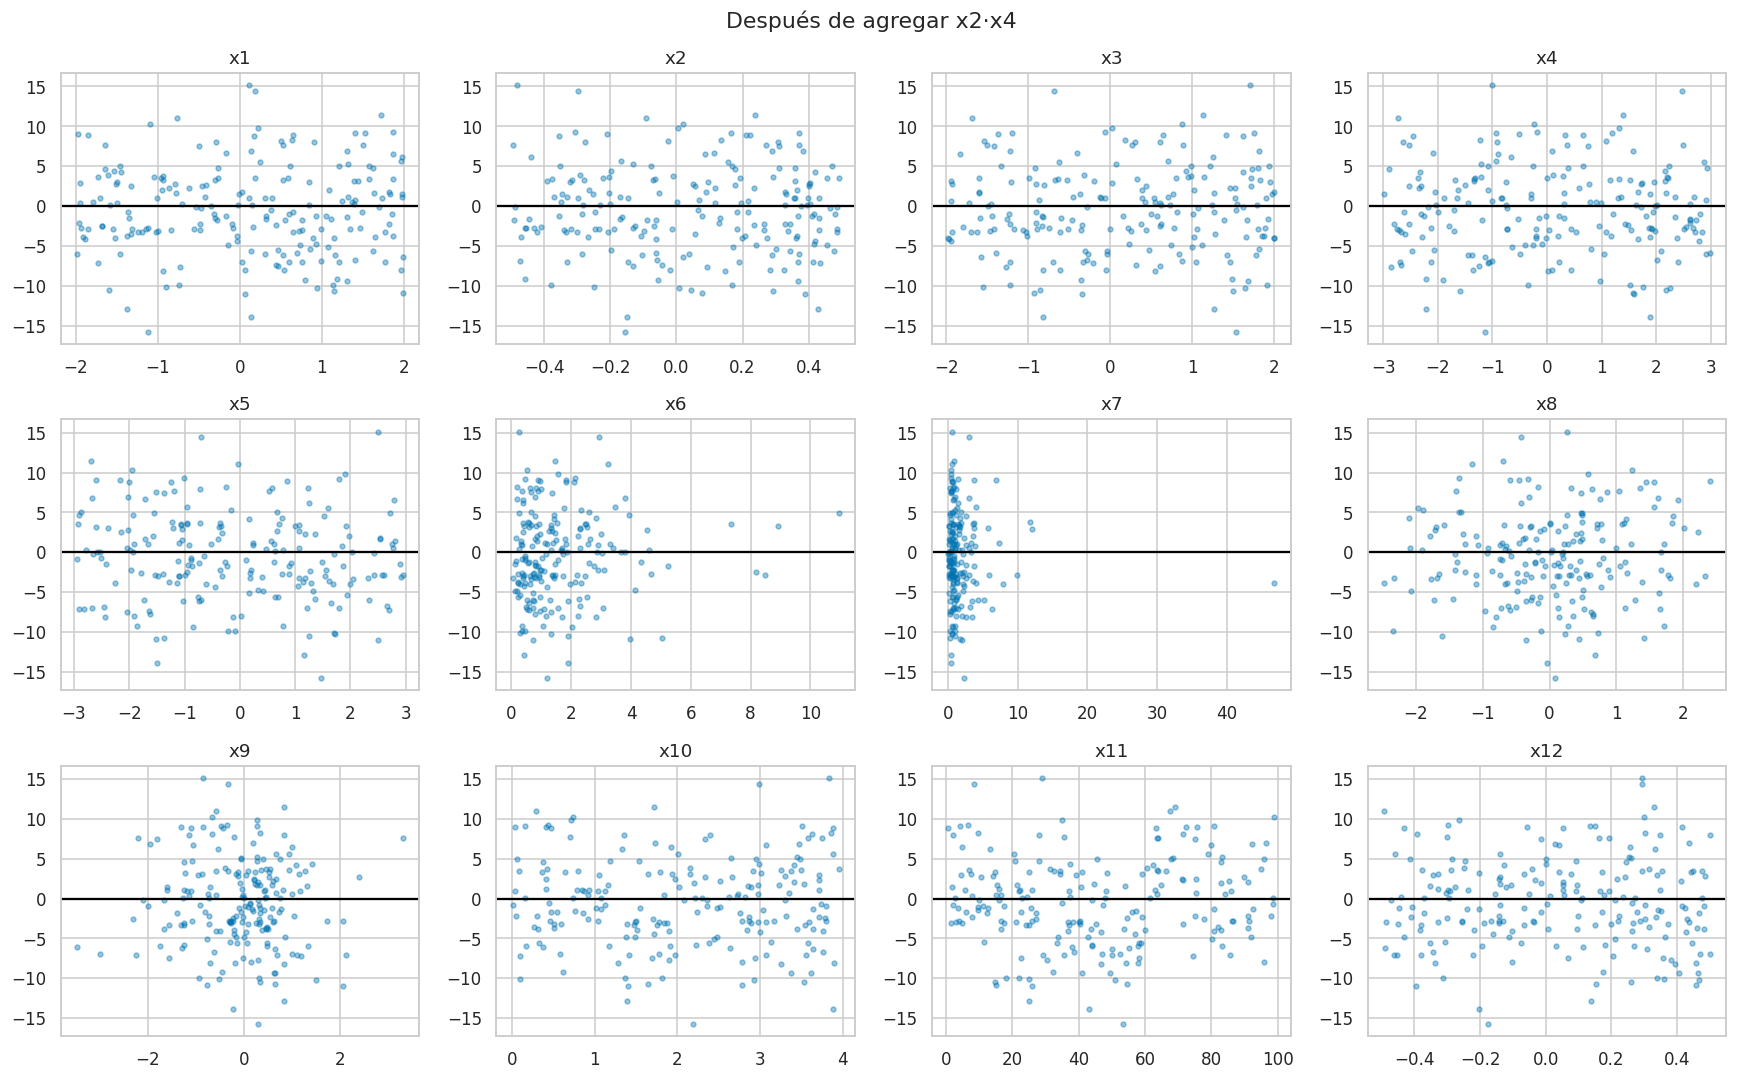

In [27]:
# TODO: agreguen lo que hayan encontrado y midan.

terminos["x2_x4"] = lambda d: d["x2"] * d["x4"]
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Con x2·x4 -> MSE {mse:.2f}")

grafica_residuales(residuales, "Después de agregar x2·x4")

In [28]:
# Sin el ruido de la interacción, el panel de x11 muestra un SALTO, no una rampa.
# Residual promedio en tramos de 10 unidades de x11:
for inicio in range(0, 100, 10):
    en_tramo = (X_val["x11"] > inicio) & (X_val["x11"] <= inicio + 10)
    print(f"x11 entre {inicio:2d} y {inicio + 10:3d}: residual promedio {residuales[en_tramo].mean():6.2f}")

# Un salto no se arregla con un polinomio:
terminos["x11_sq"] = lambda d: d["x11"] ** 2
modelo, mse, residuales, _ = ajusta(terminos)
print(f"\nCon x11² -> MSE {mse:.2f}   (antes 31.19: casi no ayuda, callejón sin salida)")
del terminos["x11_sq"]

x11 entre  0 y  10: residual promedio   2.27
x11 entre 10 y  20: residual promedio  -1.63
x11 entre 20 y  30: residual promedio  -1.20
x11 entre 30 y  40: residual promedio  -0.97
x11 entre 40 y  50: residual promedio  -3.32
x11 entre 50 y  60: residual promedio  -5.30
x11 entre 60 y  70: residual promedio   4.92
x11 entre 70 y  80: residual promedio   2.76
x11 entre 80 y  90: residual promedio  -0.54
x11 entre 90 y 100: residual promedio   0.62

Con x11² -> MSE 29.41   (antes 31.19: casi no ayuda, callejón sin salida)


Escalón en 55 -> MSE 28.39
Escalón en 65 -> MSE 28.73
Escalón en 60 -> MSE 25.09   <- el mejor, se queda


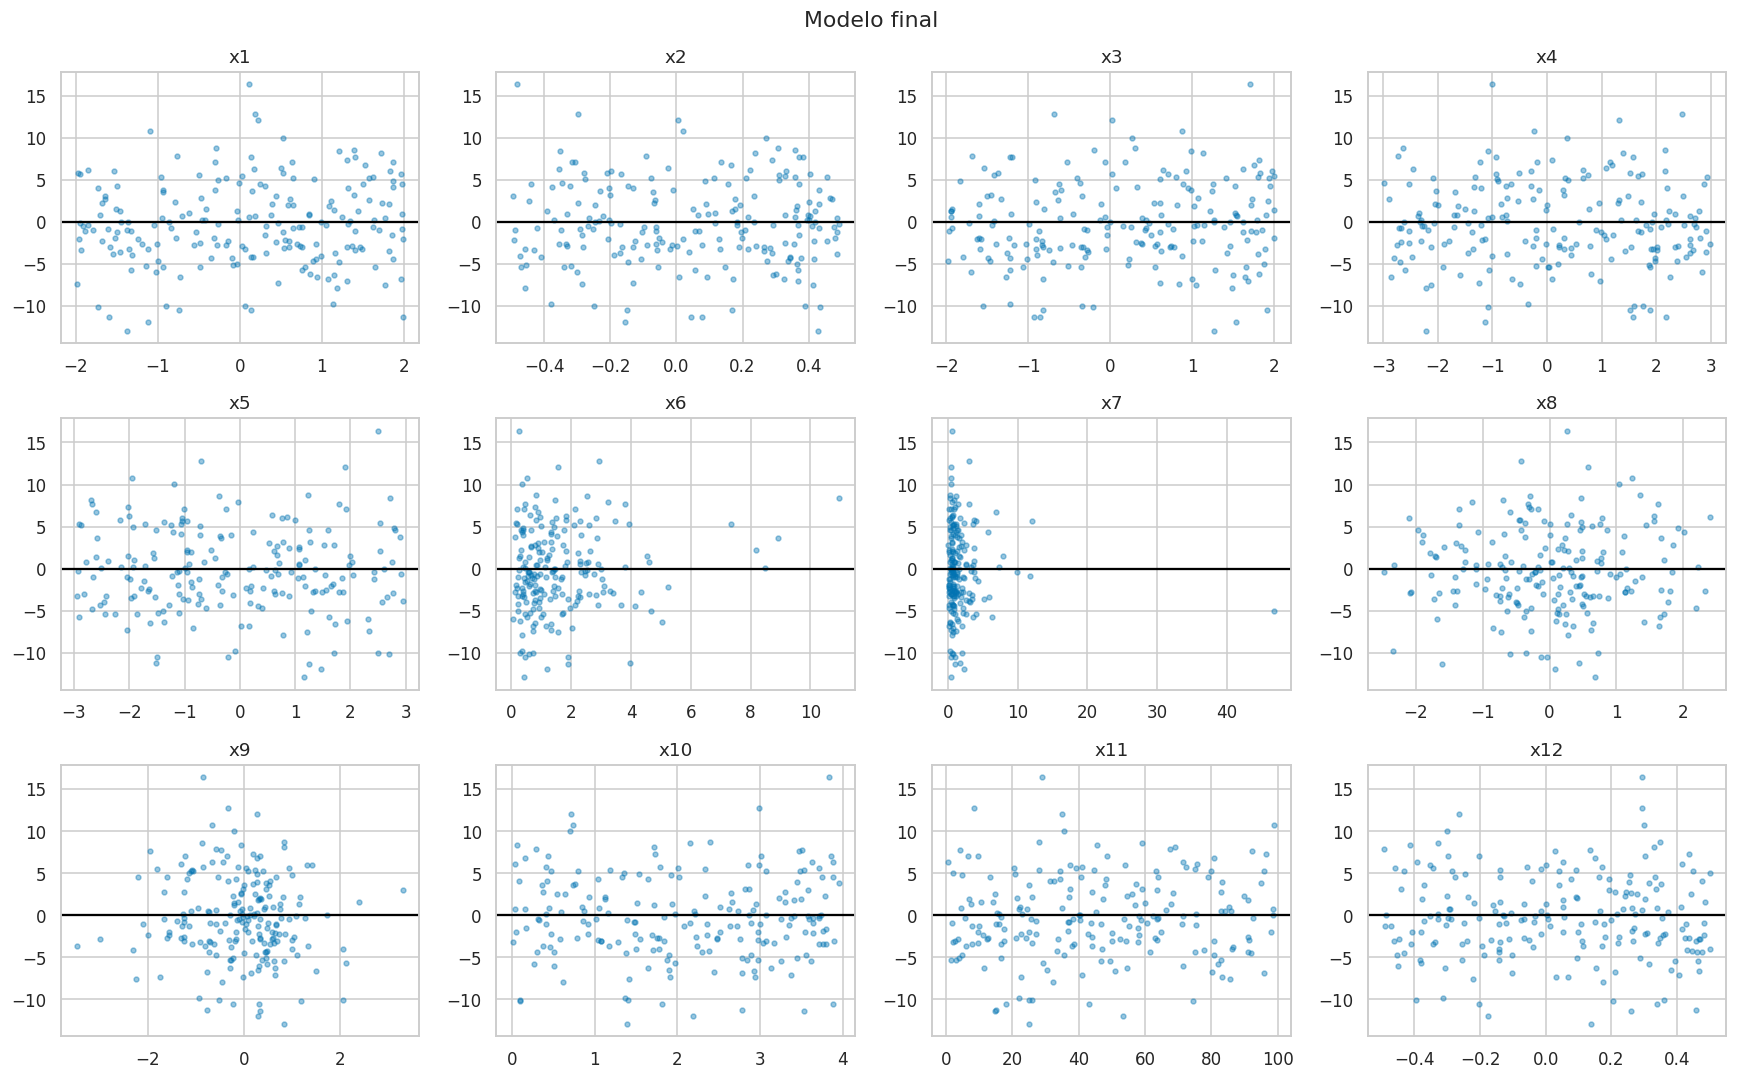

In [29]:
# Se arregla con una columna indicadora: vale 1 si x11 pasa del umbral y 0 si no.
# Pruebo tres umbrales alrededor de donde se ve el salto; dejo al final el mejor.
terminos["esc_x11"] = lambda d: (d["x11"] > 55).astype(float)
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Escalón en 55 -> MSE {mse:.2f}")

terminos["esc_x11"] = lambda d: (d["x11"] > 65).astype(float)
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Escalón en 65 -> MSE {mse:.2f}")

terminos["esc_x11"] = lambda d: (d["x11"] > 60).astype(float)
modelo, mse, residuales, _ = ajusta(terminos)
print(f"Escalón en 60 -> MSE {mse:.2f}   <- el mejor, se queda")

grafica_residuales(residuales, "Modelo final")

In [30]:
# Validación cruzada sobre TODO train (advertencia de la sección 0.2): una sola partición de
# 200 datos es ruidosa, y elegir entre candidatos siempre con los mismos 200 los sobreajusta.
from sklearn.model_selection import cross_val_score


def mse_cv(columnas):
    """MSE por validación cruzada de 10 pliegues de la lineal con las 12 crudas más `columnas`."""
    _, _, _, construye = ajusta(columnas)     # `ajusta` devuelve la función que arma las columnas
    puntajes = cross_val_score(LinearRegression(), construye(train), train["y"], cv=10,
                               scoring="neg_mean_squared_error")
    return -puntajes.mean()


print(f"Baseline     -> MSE por CV {mse_cv({}):.2f}")
print(f"Modelo final -> MSE por CV {mse_cv(terminos):.2f}")

# La decisión más fina fue el umbral de x11: la confirmo con CV.
terminos["esc_x11"] = lambda d: (d["x11"] > 55).astype(float)
print(f"Escalón en 55 -> MSE por CV {mse_cv(terminos):.2f}")
terminos["esc_x11"] = lambda d: (d["x11"] > 65).astype(float)
print(f"Escalón en 65 -> MSE por CV {mse_cv(terminos):.2f}")
terminos["esc_x11"] = lambda d: (d["x11"] > 60).astype(float)
print(f"Escalón en 60 -> MSE por CV {mse_cv(terminos):.2f}   <- también gana con CV")

Baseline     -> MSE por CV 131.87
Modelo final -> MSE por CV 21.09
Escalón en 55 -> MSE por CV 24.87
Escalón en 65 -> MSE por CV 24.51
Escalón en 60 -> MSE por CV 21.09   <- también gana con CV


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [31]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.

# Camino B: todas las potencias y productos hasta grado 3 -> estandarizar -> Lasso con λ por CV.

# 1) Columnas polinomiales. Se "aprenden" en entrenamiento y se aplican igual a validación.
poli = PolynomialFeatures(degree=3, include_bias=False)
P_train = poli.fit_transform(X_train)
P_val = poli.transform(X_val)

# 2) Estandarizar, con la media y desviación de ENTRENAMIENTO.
escala = StandardScaler()
P_train = escala.fit_transform(P_train)
P_val = escala.transform(P_val)

# 3) Lasso eligiendo λ por validación cruzada (tarda alrededor de un minuto).
lasso = LassoCV(cv=5, random_state=SEMILLA, max_iter=20000)
lasso.fit(P_train, y_train)

mse_lasso = mean_squared_error(y_val, lasso.predict(P_val))
print(f"MSE de validación, fuerza bruta : {mse_lasso:.2f}")
print(f"MSE de validación, modelo guiado: {mse:.2f}")

coefs = pd.Series(lasso.coef_, index=poli.get_feature_names_out(VARIABLES))
usados = coefs[coefs != 0]
print(f"Columnas generadas: {len(coefs)}, distintas de cero: {len(usados)}")

print("\nLas 10 columnas con coeficiente más grande:")
orden = usados.abs().sort_values(ascending=False).index
print(usados[orden].head(10).round(2))

MSE de validación, fuerza bruta : 57.47
MSE de validación, modelo guiado: 25.09
Columnas generadas: 454, distintas de cero: 46

Las 10 columnas con coeficiente más grande:
x3^3        6.61
x1^2        4.99
x2 x4       4.70
x11^2       2.93
x4          2.18
x7          1.08
x2 x4 x7    0.68
x7 x11      0.66
x1^2 x7     0.62
x1^2 x11    0.57
dtype: float64


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?

1. Ganó mi modelo hecho con las gráficas: MSE de validación 25.09 contra 57.47 de la fuerza bruta.
   Además el mío solo usa 6 columnas nuevas, y el Lasso se quedó con 46 de las 454 que generó.
2. Por qué ganó: PolynomialFeatures solo sabe hacer potencias y multiplicaciones entre variables. Por
   eso sí encontró x3 al cubo, x1 al cuadrado y x2 por x4, que son sus tres coeficientes más grandes.
   Pero no puede hacer un logaritmo, un seno ni un brinco, porque esas cosas no son potencias ni
   multiplicaciones. Para el brinco de x11 usó x11 al cuadrado, que se parece un poco pero no es lo
   mismo. Esas tres cosas que no puede hacer son justo la diferencia entre los dos modelos.
3. No aplica, porque la fuerza bruta perdió. Si hubiera ganado, querría decir que a mi modelo le
   faltaba alguna potencia o multiplicación que el Lasso sí encontró.
4. Con 80 datos habría 454 columnas para solo 60 datos de entrenamiento: muchas más columnas que datos.
   Con tantas columnas, algunas que son puro ruido se parecerían a y por casualidad y el Lasso las
   escogería, o de plano quitaría casi todo. Mi modelo solo agrega 6 columnas, así que todavía se podría
   ajustar, aunque con tan pocos puntos las formas en las gráficas se verían mucho menos.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | La U de x1 se arregla con valor absoluto | y contra x1 | valor absoluto de x1 | 135.20 → 102.25 el cuadrado es mejor | YO |
| 2 | La U de x1 se arregla con un cuadrado | residuales contra x1 | x1 al cuadrado | 135.20 → 99.15 | YO |
| 3 | x6 tiene casi todos los datos a la izquierda, pruebo logaritmo | histograma de x6 | log(x6) | 99.15 → 99.37 falló | YO |
| 4 | x7 está igual de cargada que x6, pruebo logaritmo también | histograma de x7 | log(x7) | 99.15 → 95.90 | YO |
| 5 | En x10 hay olas que se repiten cada 1, pruebo un seno | residuales contra x10 | sin(2π·x10) | 95.90 → 75.09 | IA |
| 6 | A lo mejor las olas de x10 están recorridas, pruebo coseno | residuales contra x10 | cos(2π·x10) | 75.09 → 75.26 falló | IA |
| 7 | La S de x3 se arregla con un cuadrado | residuales contra x3 | x3 al cuadrado | 75.09 → 77.13 | YO |
| 8 | La S de x3 se arregla con un cubo | residuales contra x3 | x3 al cubo | 75.09 → 62.16 | YO |
| 9 | Hay dos variables que se multiplican entre sí | correlación de los residuales con los 66 pares multiplicados; gráfica de x2 contra x4 con colores | x2 por x4 | 62.16 → 31.19 | IA |
| 10 | Lo que falta de x11 es una curva, pruebo al cuadrado | residuales contra x11 | x11 al cuadrado | 31.19 → 29.41 | IA |
| 11 | x11 da un brinco en 60 | promedio de los residuales por pedazos de x11; probar 55, 60 y 65 | 1 si x11 > 60, 0 si no | 31.19 → 25.09 | IA |

Los MSE de la tabla son de validación. Con validación cruzada de 10 pliegues: baseline 131.87 y modelo final 21.09.

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

y ≈ 2.8 + 4.8·x1² + 2.5·x3³ + 1.7·x4 + 10.8·x2·x4 + 3.5·log(x7) + 6.2·sin(2π·x10) + 9.4·(1 si x11 > 60) + ruido

- El ruido parece ser de más o menos ±4.6, porque el MSE que ya no pude bajar es como 21 y su raíz es 4.6.
- Las que no afectan en nada son x5, x6, x8, x9 y x12: sus coeficientes salen casi en 0.
- x1, x2, x3, x7, x10 y x11 no entran como línea recta, solo entran transformadas.
- Los números salen cerca de números redondos (5, 2.5, 6, 10 y el brinco en 60), así que creo que así
  definieron la función.
- Una duda que me quedó: x3 al cubo y x3 más sin(x3) dan casi el mismo error, con estos datos no se
  puede saber cuál es. Me quedé con el cubo porque es más simple.

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

Trabajé la tarea con Copilot, que sí pudo correr código sobre mis datos. Aun así se equivocó:
después de los primeros cuatro términos (antes de encontrar la interacción) buscó automáticamente el
mejor umbral para un escalón en x11 y señaló x11 ≈ 13. Era falso. En ese momento el residual
todavía cargaba todo el efecto de x2·x4 (el MSE estaba en ~62) y ese ruido tapaba el salto real.
Se detectó al repetir el residual por tramos de x11 después de agregar x2*x4: el promedio pasa
de −5.3 en (50, 60] a +4.9 en (60, 70], y el barrido de umbrales tiene su mínimo claro en 60
(25.09 contra 28.4 en 55 y 28.7 en 65). Lección: el orden importa — un efecto grande sin modelar
contamina la búsqueda de los chicos.

Otras sugerencias de la IA que no sirvieron para mis datos: log(x6) "porque es sesgada"
(99.15 → 99.37) y `cos(2π·x10)` por si había desfase (75.09 → 75.26).

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

Paré cuando llegué a MSE 25.09 en validación y 21.09 con validación cruzada, porque parece que lo que
queda ya es puro ruido:

- En la última gráfica de residuales ya ninguna variable tiene forma: todas las nubes quedan parejas
  alrededor del 0, no suben, no bajan y no hacen olas.
- Los últimos intentos ya casi no movían el MSE (por ejemplo x11 al cuadrado solo bajó de 31.19 a 29.41),
  y lo único que sí bajó fue el brinco en 60.
- El brinco en 60 lo revisé también con validación cruzada para no creerle a una sola partición:
  24.87 con 55, 21.09 con 60 y 24.51 con 65.
- La diferencia entre 25.09 (validación) y 21.09 (validación cruzada) creo que es suerte: validación son
  solo 200 datos y le tocaron un poco difíciles. Le creo más a la validación cruzada porque usa los 800.

MSE meta según /validar: 23.34. Mi modelo da 21.09 con validación cruzada, o sea 2.25 por debajo de la
meta, así que ya no tenía caso seguir buscando términos: lo que queda es ruido.

El bot también dice que el baseline lineal da 107.51 en los datos de prueba. A mí me salió 135.20 en
validación y 131.87 con validación cruzada. No coinciden porque se miden en datos distintos (el bot usa
los 400 de prueba y yo solo tengo los 800 de entrenamiento), y por eso mi 21.09 tampoco va a salir igualito
en la calificación.

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [32]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    "x1_sq": lambda d: d["x1"] ** 2,
    "log_x7": lambda d: np.log(d["x7"]),
    "sin_x10": lambda d: np.sin(2 * np.pi * d["x10"]),
    "x3_cu": lambda d: d["x3"] ** 3,
    "x2_x4": lambda d: d["x2"] * d["x4"],
    "esc_x11": lambda d: (d["x11"] > 60).astype(float),
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 25.09

Escrito: entregas/tarea-01/v65250145/predicciones.csv
400 predicciones, rango -19.70 a 50.94


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.